# Week 1: XGBoost for Renewable Energy Forecasting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_GITHUB/ai-competition/blob/main/01-forecasting/forecasting_xgboost.ipynb)

**เป้าหมาย:** เรียนรู้ XGBoost time series forecasting ด้วย synthetic Solar/Wind dataset

**หลังจาก notebook นี้ คุณจะ:**
- เข้าใจ feature engineering สำหรับ time series
- Train XGBoost model สำหรับ forecasting
- Evaluate ด้วย RMSE, MAE, MAPE
- Apply กับ PEA dataset จริงได้ทันที

## 0. Install Dependencies

In [1]:
!pip install xgboost scikit-learn matplotlib seaborn pandas numpy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('XGBoost version:', xgb.__version__)

XGBoost version: 3.3.0


## 1. สร้าง Dataset (Synthetic Solar + Wind)

**ทำไมใช้ synthetic?** เพราะยังไม่ได้ data จริงจาก PEA

Synthetic dataset นี้มี pattern เหมือน real solar/wind:
- **Solar:** มีเฉพาะกลางวัน, ขึ้นอยู่กับเดือน (ฤดูกาล)
- **Wind:** มีตลอด 24 ชม., pattern ไม่แน่นอนกว่า

เมื่อได้ data จริง แค่เปลี่ยน section นี้เป็น `pd.read_csv('pea_data.csv')`

In [ ]:
def create_synthetic_dataset(start='2023-01-01', end='2024-12-31', freq='1h', seed=42):
    """
    สร้าง synthetic Solar + Wind power data
    Unit: MW (megawatt)
    """
    np.random.seed(seed)
    idx = pd.date_range(start=start, end=end, freq=freq)
    n = len(idx)
    
    hour = idx.hour
    month = idx.month
    
    # --- Solar ---
    # peak ช่วง 10:00-14:00, ขึ้นอยู่กับเดือน (ต.ค.-เม.ย. = แดดจัด)
    solar_hour_curve = np.maximum(0, np.sin(np.pi * (hour - 6) / 12))  # 0 กลางคืน
    solar_season = 1 + 0.3 * np.cos(2 * np.pi * (month - 1) / 12)     # peak เดือน 1
    solar_capacity = 10  # MW
    solar = solar_capacity * solar_hour_curve * solar_season
    solar += np.random.normal(0, 0.3, n) * (solar > 0)  # noise เฉพาะตอนกลางวัน
    solar = np.maximum(0, solar)  # ไม่ติดลบ
    
    # --- Wind ---
    # มีตลอด 24 ชม., มี weekly pattern (ลมแรงช่วงต้นสัปดาห์)
    wind_base = 5 + 2 * np.sin(2 * np.pi * idx.dayofweek / 7)
    wind_daily = 1 + 0.5 * np.sin(2 * np.pi * (hour - 14) / 24)  # peak บ่าย
    wind_capacity = 8  # MW
    wind = wind_capacity * (wind_base / 7) * wind_daily
    wind += np.random.normal(0, 0.8, n)  # noise สูงกว่า solar
    wind = np.maximum(0, wind)
    
    df = pd.DataFrame({'solar_mw': solar, 'wind_mw': wind}, index=idx)
    return df

df = create_synthetic_dataset()
print(f'Dataset: {len(df):,} rows | {df.index[0]} → {df.index[-1]}')
df.head()

Dataset: 17,521 rows | 2023-01-01 00:00:00 → 2024-12-31 00:00:00


,solar_mw,wind_mw
2024-12-30 20:00:00,0.0,7.947033
2024-12-30 21:00:00,0.0,8.081186
2024-12-30 22:00:00,0.0,7.973041
2024-12-30 23:00:00,0.0,7.429690
2024-12-31 00:00:00,0.0,9.927076


## 2. EDA — ดู Pattern

**ก่อน train model ต้องเข้าใจ data ก่อน** — plot ดูก่อนเสมอ

/tmp/ipykernel_1207/1409505028.py:15: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/1409505028.py:15: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/1409505028.py:15: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/1409505028.py:15: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/1409505028.py:15: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/1409505028.py:15: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/1409505028.py:15: UserWarning: Glyph 3660 (\N{THAI CHARACTER THANTHAKHAT}) missing from font(s) DejaVu 

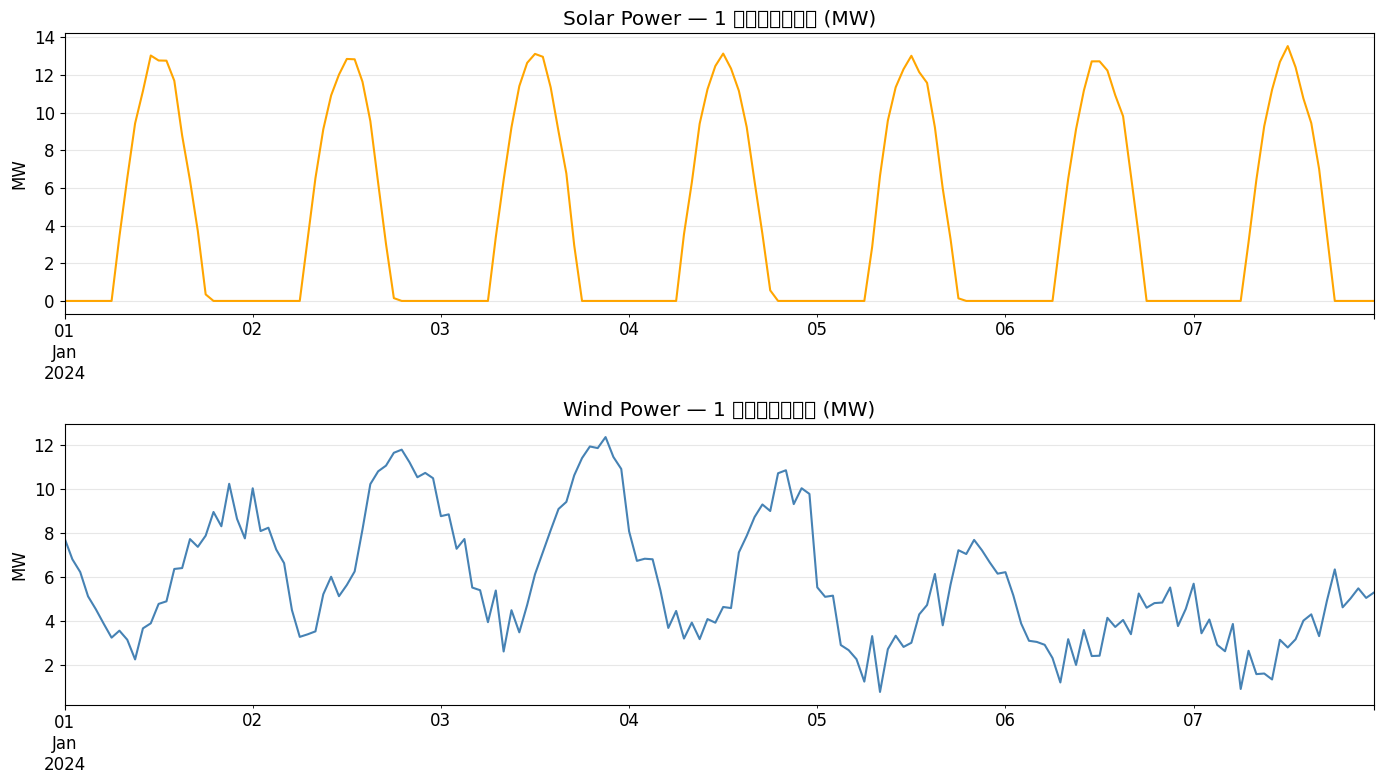

In [5]:
# Plot 1 สัปดาห์
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

week = df['2024-01-01':'2024-01-07']
week['solar_mw'].plot(ax=ax1, color='orange', linewidth=1.5)
ax1.set_title('Solar Power — 1 สัปดาห์ (MW)')
ax1.set_ylabel('MW')
ax1.grid(alpha=0.3)

week['wind_mw'].plot(ax=ax2, color='steelblue', linewidth=1.5)
ax2.set_title('Wind Power — 1 สัปดาห์ (MW)')
ax2.set_ylabel('MW')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1207/4042433015.py:16: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/4042433015.py:16: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/4042433015.py:16: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/4042433015.py:16: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/4042433015.py:16: UserWarning: Glyph 3593 (\N{THAI CHARACTER CHO CHING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/4042433015.py:16: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1207/4042433015.py:16: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu San

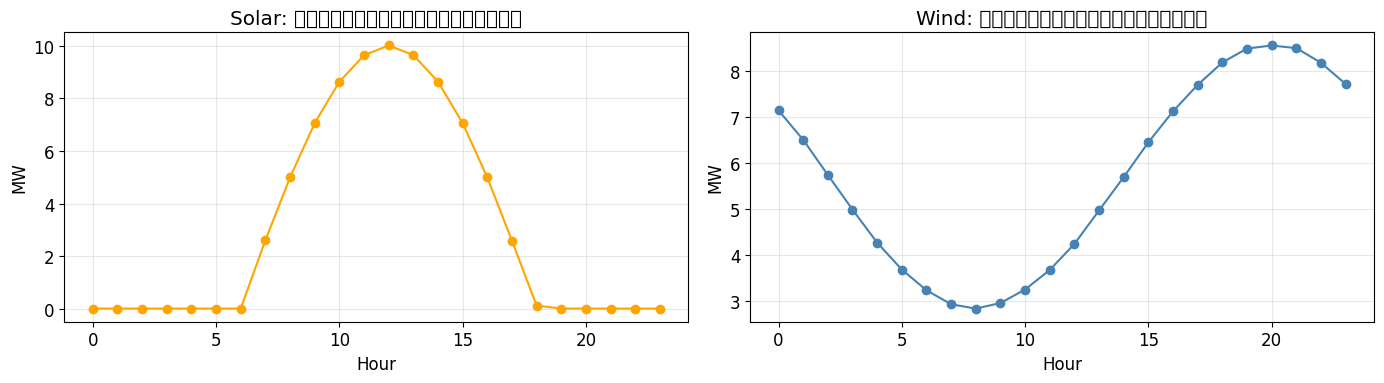

In [6]:
# Hourly average — ดู daily pattern
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

df.groupby(df.index.hour)['solar_mw'].mean().plot(ax=ax1, color='orange', marker='o')
ax1.set_title('Solar: ค่าเฉลี่ยรายชั่วโมง')
ax1.set_xlabel('Hour')
ax1.set_ylabel('MW')
ax1.grid(alpha=0.3)

df.groupby(df.index.hour)['wind_mw'].mean().plot(ax=ax2, color='steelblue', marker='o')
ax2.set_title('Wind: ค่าเฉลี่ยรายชั่วโมง')
ax2.set_xlabel('Hour')
ax2.set_ylabel('MW')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ข้อสังเกต:
# Solar: peak ชัดเจน ช่วง 10-14 น.
# Wind: มีทุกชั่วโมง, peak เล็กน้อยช่วงบ่าย

## 3. Feature Engineering

นี่คือหัวใจของ XGBoost time series

**หลักการ:** แปลง timestamp เป็น features ที่ model เข้าใจได้

```
2024-01-15 14:00  →  hour=14, month=1, dow=0, lag_1h=4.2, lag_24h=5.1, ...
```

In [ ]:
def create_features(df, target_col, is_solar=True):
    """
    สร้าง features สำหรับ XGBoost forecasting
    
    Parameters:
        df: DataFrame with DatetimeIndex
        target_col: ชื่อ column ที่ต้องการ predict
        is_solar: True=solar features, False=wind features
    """
    data = df.copy()
    
    # --- Time Features ---
    data['hour']        = data.index.hour
    data['day_of_week'] = data.index.dayofweek   # 0=จันทร์
    data['month']       = data.index.month
    data['quarter']     = data.index.quarter
    data['is_weekend']  = (data['day_of_week'] >= 5).astype(int)
    
    # Cyclical encoding — บอก model ว่า hour 23 ใกล้กับ hour 0
    data['hour_sin']  = np.sin(2 * np.pi * data['hour'] / 24)
    data['hour_cos']  = np.cos(2 * np.pi * data['hour'] / 24)
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
    
    # --- Lag Features ---
    target = data[target_col]
    data['lag_1h']   = target.shift(1)
    data['lag_2h']   = target.shift(2)
    data['lag_3h']   = target.shift(3)
    data['lag_6h']   = target.shift(6)
    data['lag_12h']  = target.shift(12)
    data['lag_24h']  = target.shift(24)   # เมื่อวานนี้เวลาเดียวกัน
    data['lag_48h']  = target.shift(48)
    data['lag_168h'] = target.shift(168)  # สัปดาห์ที่แล้วเวลาเดียวกัน ← สำคัญมาก
    
    # --- Rolling Features ---
    data['rolling_mean_3h']  = target.shift(1).rolling(3).mean()
    data['rolling_mean_6h']  = target.shift(1).rolling(6).mean()
    data['rolling_mean_24h'] = target.shift(1).rolling(24).mean()
    data['rolling_std_24h']  = target.shift(1).rolling(24).std()
    data['rolling_max_24h']  = target.shift(1).rolling(24).max()
    
    # --- Solar-specific Features ---
    if is_solar:
        # Solar ผลิตได้เฉพาะกลางวัน — feature นี้ช่วยมาก
        data['is_daylight'] = ((data['hour'] >= 6) & (data['hour'] <= 18)).astype(int)
        # ยิ่งดวงอาทิตย์สูงยิ่งผลิตได้มาก (approximate)
        data['solar_elevation'] = np.maximum(0, np.sin(np.pi * (data['hour'] - 6) / 12))
    
    # Drop rows ที่มี NaN (จาก lag)
    data = data.dropna()
    
    return data

# สร้าง features สำหรับ Solar
solar_df = create_features(df[['solar_mw']], target_col='solar_mw', is_solar=True)
print(f'Features: {solar_df.shape[1]-1} | Rows: {len(solar_df):,}')
print('\nFeature list:')
features = [c for c in solar_df.columns if c != 'solar_mw']
print(features)

## 4. Train/Test Split

**สำคัญ:** Time series ต้อง split แบบ chronological — ห้าม random split!

```
Train: ปี 2023         | Test: ปี 2024
[====================] | [==========]
        อดีต                 อนาคต
```

In [ ]:
# Chronological split — 80% train, 20% test
split_date = '2024-05-01'

train = solar_df[solar_df.index < split_date]
test  = solar_df[solar_df.index >= split_date]

features = [c for c in solar_df.columns if c != 'solar_mw']
target   = 'solar_mw'

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

print(f'Train: {len(X_train):,} rows ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Test:  {len(X_test):,} rows  ({X_test.index[0].date()} → {X_test.index[-1].date()})')

## 5. Train XGBoost Model

In [ ]:
model = xgb.XGBRegressor(
    n_estimators    = 500,    # จำนวน trees
    max_depth       = 6,      # ความลึกต่อ tree (ใหญ่ขึ้น = complex ขึ้น)
    learning_rate   = 0.05,   # ขนาดก้าว (เล็ก = stable แต่ช้า)
    subsample       = 0.8,    # ใช้ 80% ของ data ต่อ tree (ป้องกัน overfit)
    colsample_bytree= 0.8,    # ใช้ 80% ของ features ต่อ tree
    min_child_weight= 5,      # minimum samples ใน leaf
    random_state    = 42,
    n_jobs          = -1      # ใช้ CPU ทุก core
)

model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = 100  # print ทุก 100 iterations
)

print('\nTraining done!')

## 6. Evaluate — วัดความแม่น

In [ ]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: ระวัง division by zero เมื่อ y_true = 0 (กลางคืน)
    mask = y_true > 0.1
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    print(f'{label}')
    print(f'  MAE  = {mae:.3f} MW  (ค่าเฉลี่ยผิดพลาด)')
    print(f'  RMSE = {rmse:.3f} MW  (ลงโทษ error ใหญ่)')
    print(f'  MAPE = {mape:.1f}%    (% ผิดพลาดช่วงกลางวัน)')
    return mae, rmse, mape

y_pred = model.predict(X_test)
y_pred = np.maximum(0, y_pred)  # ไม่ติดลบ

evaluate(y_test.values, y_pred, label='Solar Forecast')

## 7. Visualize — ดูผล

In [ ]:
# Plot 5 วัน
plot_days = 5 * 24  # 5 วัน × 24 ชั่วโมง

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index[:plot_days], y_test.values[:plot_days],
        label='Actual', color='orange', linewidth=2)
ax.plot(y_test.index[:plot_days], y_pred[:plot_days],
        label='Predicted', color='blue', linewidth=1.5, linestyle='--')
ax.set_title('Solar Power Forecast vs Actual (5 วัน)')
ax.set_ylabel('MW')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance — features ไหนสำคัญที่สุด?
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(15).plot(
    kind='barh', x='feature', y='importance',
    ax=ax, color='steelblue', legend=False
)
ax.set_title('Top 15 Feature Importance')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importance.head())

## 8. ทำเหมือนกันกับ Wind

In [ ]:
# Wind forecast — แค่เปลี่ยน target_col + is_solar=False
wind_df = create_features(df[['wind_mw']], target_col='wind_mw', is_solar=False)

train_w = wind_df[wind_df.index < split_date]
test_w  = wind_df[wind_df.index >= split_date]
features_w = [c for c in wind_df.columns if c != 'wind_mw']

model_wind = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
model_wind.fit(
    train_w[features_w], train_w['wind_mw'],
    eval_set=[(test_w[features_w], test_w['wind_mw'])],
    verbose=False
)

y_pred_wind = np.maximum(0, model_wind.predict(test_w[features_w]))
evaluate(test_w['wind_mw'].values, y_pred_wind, label='Wind Forecast')

## 9. Hyperparameter Tuning (Optional)

ถ้าอยากได้ accuracy สูงขึ้น ลอง tune parameters เหล่านี้

In [ ]:
# Quick grid search — เลือก parameters ที่ดีที่สุด
from sklearn.model_selection import GridSearchCV

# ลด scope สำหรับ speed — เปลี่ยนได้ตามต้องการ
param_grid = {
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [200, 500]
}

# หมายเหตุ: GridSearchCV กับ time series ต้องระวัง
# ควรใช้ TimeSeriesSplit แทน random CV
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)

gs = GridSearchCV(
    xgb.XGBRegressor(subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1
)
gs.fit(X_train, y_train)

print('Best params:', gs.best_params_)
print('Best RMSE:', -gs.best_score_)

## 10. เตรียม Pipeline สำหรับ Competition Day

**วันแข่ง:** รับโจทย์ → กรอกค่า missing → ส่ง CSV ก่อน 16:30

Code ด้านล่างนี้เตรียมไว้สำหรับ apply กับ data จริง

In [ ]:
def predict_missing_values(full_data_path, output_path, model_solar, model_wind):
    """
    รับ CSV ที่มี missing values → เติมด้วย model → ส่งออก CSV
    
    Expected CSV format:
        datetime, solar_mw, wind_mw
        2024-01-01 00:00:00, 0.0, 3.2
        2024-01-01 01:00:00, NaN, 4.1  ← missing
        ...
    """
    df_raw = pd.read_csv(full_data_path, parse_dates=['datetime'], index_col='datetime')
    
    # สร้าง features จาก full time index (รวม missing rows)
    solar_feats = create_features(df_raw[['solar_mw']], 'solar_mw', is_solar=True)
    wind_feats  = create_features(df_raw[['wind_mw']],  'wind_mw',  is_solar=False)
    
    feat_cols_solar = [c for c in solar_feats.columns if c != 'solar_mw']
    feat_cols_wind  = [c for c in wind_feats.columns  if c != 'wind_mw']
    
    # Predict เฉพาะ rows ที่ missing
    missing_solar = df_raw['solar_mw'].isna()
    missing_wind  = df_raw['wind_mw'].isna()
    
    result = df_raw.copy()
    
    if missing_solar.any():
        pred_solar = model_solar.predict(solar_feats.loc[missing_solar, feat_cols_solar])
        result.loc[missing_solar, 'solar_mw'] = np.maximum(0, pred_solar)
    
    if missing_wind.any():
        pred_wind = model_wind.predict(wind_feats.loc[missing_wind, feat_cols_wind])
        result.loc[missing_wind, 'wind_mw'] = np.maximum(0, pred_wind)
    
    result.to_csv(output_path)
    print(f'Saved: {output_path}')
    print(f'Filled solar: {missing_solar.sum()} rows')
    print(f'Filled wind:  {missing_wind.sum()} rows')
    return result

# ใช้งาน:
# predict_missing_values('pea_competition_data.csv', 'submission.csv', model, model_wind)

print('Pipeline ready — รอ data จริงจาก PEA')

## Summary

สิ่งที่เรียนรู้ใน notebook นี้:

| Step | สิ่งที่ทำ |
|------|----------|
| EDA | ดู pattern solar vs wind — แตกต่างกันมาก |
| Feature Engineering | Time + Lag + Rolling + Solar-specific features |
| Train/Test Split | Chronological เท่านั้น — ห้าม random |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate` |
| Evaluate | MAE, RMSE, MAPE |
| Feature Importance | ดูว่า lag_168h (สัปดาห์ที่แล้ว) สำคัญแค่ไหน |
| Tuning | TimeSeriesSplit + GridSearchCV |
| Pipeline | พร้อม apply วันแข่ง |

---

**Next: Week 2 — Image Processing (YOLOv26)**